# 🧠 Suicide Detection NLP System
### Production-Grade 2-Class Classifier | RoBERTa + DistilBERT
---
**Classes:**
- `0` → non-suicide
- `1` → suicidal (direct intent)

**Pipeline:** Data Prep → Tokenization → Training → Evaluation → Inference

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 📦 Cell 1: Install Dependencies

In [ ]:
!pip install transformers datasets scikit-learn nltk imbalanced-learn accelerate -q

## 📚 Cell 2: Imports

In [ ]:
import os
import re
import html
import unicodedata
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch import nn
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score
)

from transformers import (
    RobertaTokenizer, RobertaForSequenceClassification,
    DebertaTokenizer, DebertaForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification,
    Trainer, TrainingArguments,
    EarlyStoppingCallback,
)

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import wordnet

warnings.filterwarnings('ignore')
print("✅ All imports successful")

✅ All imports successful


## ⚙️ Cell 4: Global Config

In [ ]:
# ── Paths ──────────────────────────────────────────────────
DATA_PATH        = "/content/drive/MyDrive/Colab Notebooks/suicide detection/Suicide_Detection.csv"
SAVE_DIR_ROBERTA = "/content/drive/MyDrive/Colab Notebooks/suicide detection/roberta_model"
SAVE_DIR_DISTILBERT = "/content/drive/MyDrive/Colab Notebooks/suicide detection/distilbert_model"
SAVE_DIR_DEBERTA = "/content/drive/MyDrive/Colab Notebooks/suicide detection/deberta_model"
# ── Model names ─────────────────────────────────────────────
ROBERTA_MODEL    = "roberta-base"
DISTILBERT_MODEL = "distilbert-base-uncased"
DEBERTA_MODEL    = "microsoft/deberta-base"
# ── Hyperparameters ─────────────────────────────────────────
MAX_LEN    = 256
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5
WEIGHT_DECAY = 0.01
NUM_LABELS = 2
CONFIDENCE_THRESHOLD = 0.60

# ── Device ──────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")

✅ Using device: cuda


## 🧹 Cell 5: Text Cleaning Functions

In [ ]:
def fix_encoding(text):
    """Fix common encoding artifacts like â€™ → ' """
    try:
        text = text.encode('latin-1').decode('utf-8')
    except Exception:
        pass
    text = unicodedata.normalize('NFKD', text)
    encoding_map = {
        'â€™': "'",  'â€œ': '"',  'â€': '"',
        'â€"': '—', 'â€"': '–',  'Ã©': 'é',
        'Ã ': 'à',  'â€˜': "'", 'Â': '',
        'â€¦': '...','&amp;': '&','&lt;': '<',
        '&gt;': '>', '&nbsp;': ' ', '&quot;': '"',
    }
    for bad, good in encoding_map.items():
        text = text.replace(bad, good)
    return text

def remove_html(text):
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    return text

def remove_urls(text):
    return re.sub(r'http\S+|www\.\S+', ' ', text)

def normalize_emojis(text):
    return re.sub(r'[^\x00-\x7F]+', ' ', text)

def clean_text(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    text = fix_encoding(text)
    text = remove_html(text)
    text = remove_urls(text)
    text = normalize_emojis(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("✅ Text cleaning functions defined")

✅ Text cleaning functions defined


## 🏷️ Cell 6: Label Engineering (3-Class)

In [ ]:
# CELL 6: Label Engineering (2-Class - Original Labels)
def assign_label(row):
    """
    0 = non-suicide
    1 = suicide
    """
    original_label = str(row['class']).strip().lower()
    if original_label == 'non-suicide':
        return 0
    return 1

print("✅ 2-class label function defined")

✅ 2-class label function defined


## 📂 Cell 7: Load & Prepare Dataset

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df.shape}")
print("Original class distribution:")
print(df['class'].value_counts())

# Drop nulls & very short texts
df = df.dropna(subset=['text', 'class'])
df = df[df['text'].str.strip().str.len() > 5].reset_index(drop=True)

# Clean text
df['text'] = df['text'].apply(clean_text)
df = df[df['text'].str.len() > 5].reset_index(drop=True)

# Assign 3-class labels
df['label'] = df.apply(assign_label, axis=1)

print("\n✅ Label distribution after 2-class engineering:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True).round(3))




Raw shape: (232074, 3)
Original class distribution:
class
suicide        116037
non-suicide    116037
Name: count, dtype: int64

✅ Label distribution after 2-class engineering:
label
1    116026
0    115987
Name: count, dtype: int64
label
1    0.5
0    0.5
Name: proportion, dtype: float64


## ✂️ Cell 8: Stratified Train / Val / Test Split (70/15/15)

In [ ]:
train_df, temp_df = train_test_split(
    df[['text', 'label']], test_size=0.30,
    stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['label'], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"✅ Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain label distribution:")
print(train_df['label'].value_counts())

✅ Train: 162409 | Val: 34802 | Test: 34802

Train label distribution:
label
1    81218
0    81191
Name: count, dtype: int64


In [ ]:
# CELL 8.5: Balance & Subsample to 100K Total
# 50,000 per class → 100,000 total (perfectly balanced)

SAMPLES_PER_CLASS = 50_000

print("Before sampling:")
print(train_df['label'].value_counts())
print(f"Total: {len(train_df)}\n")

sampled_parts = []
for lbl in [0, 1]:
    class_df = train_df[train_df['label'] == lbl]
    n = min(SAMPLES_PER_CLASS, len(class_df))
    sampled_parts.append(class_df.sample(n=n, random_state=42))

train_df = pd.concat(sampled_parts, ignore_index=True)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("After 100K balanced sampling:")
print(train_df['label'].value_counts())
print(f"Total training samples: {len(train_df)}")

Before sampling:
label
1    81218
0    81191
Name: count, dtype: int64
Total: 162409

After 100K balanced sampling:
label
1    50000
0    50000
Name: count, dtype: int64
Total training samples: 100000


## ⚖️ Cell 9: Compute Class Weights (Imbalance Handling)

In [ ]:
# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.array([0, 1]),
#     y=train_df['label'].values
# )
classes = np.unique(train_df['label'].values)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label'].values
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"✅ Class weights: {class_weights}")
print(f"   0=non-suicide: {class_weights[0]:.3f}")
print(f"   1=suicidal:    {class_weights[1]:.3f}")


✅ Class weights: [1. 1.]
   0=non-suicide: 1.000
   1=suicidal:    1.000


In [ ]:
classes=np.unique(train_df['label'].values)

[0 1]


## 🗂️ Cell 11: PyTorch Dataset Class

In [ ]:
class SuicideDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx]).strip() or "empty"
        enc  = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }

print("✅ SuicideDataset class defined")

✅ SuicideDataset class defined


## 🏋️ Cell 12: Custom Weighted Trainer + Metrics

In [ ]:
class WeightedTrainer(Trainer):
    """HuggingFace Trainer with weighted CrossEntropyLoss for class imbalance"""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1_macro':    f1_score(labels, preds, average='macro',    zero_division=0),
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
    }

print("✅ WeightedTrainer and compute_metrics defined")

✅ WeightedTrainer and compute_metrics defined


## 🚀 Cell 13: Universal Training Function

In [ ]:
def train_model(model_name, save_dir, train_df, val_df, max_len=MAX_LEN):
    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")

    # Load tokenizer & model
    if 'roberta' in model_name:
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model     = RobertaForSequenceClassification.from_pretrained(
                        model_name, num_labels=NUM_LABELS)
    elif 'deberta' in model_name:
      tokenizer = DebertaTokenizer.from_pretrained(model_name)
      model     = DebertaForSequenceClassification.from_pretrained(
                    model_name, num_labels=NUM_LABELS)
    else:
        tokenizer = DistilBertTokenizer.from_pretrained(model_name)
        model     = DistilBertForSequenceClassification.from_pretrained(
                        model_name, num_labels=NUM_LABELS)

    model.to(DEVICE)

    # Build datasets
    train_ds = SuicideDataset(
        train_df['text'].tolist(), train_df['label'].tolist(), tokenizer, max_len)
    val_ds = SuicideDataset(
        val_df['text'].tolist(), val_df['label'].tolist(), tokenizer, max_len)

    # Training arguments
    args = TrainingArguments(
        output_dir                  = save_dir,
        num_train_epochs            = EPOCHS,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = BATCH_SIZE,
        learning_rate               = LR,
        weight_decay                = WEIGHT_DECAY,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "eval_loss",
        greater_is_better           = False,
        logging_dir                 = f"{save_dir}/logs",
        logging_steps               = 50,
        warmup_ratio                = 0.1,
        lr_scheduler_type           ="linear",
        fp16                        = False,
        # fp16                        = torch.cuda.is_available(),
        report_to                   = "none",
        seed                        = 42,
    )

    trainer = WeightedTrainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics,
        class_weights   = class_weights_tensor,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    # Save model + tokenizer
    os.makedirs(save_dir, exist_ok=True)
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"\n✅ Model saved → {save_dir}")

    return model, tokenizer

print("✅ train_model() function ready")

✅ train_model() function ready


## 🤖 Cell 14: Train RoBERTa

In [ ]:
roberta_model, roberta_tokenizer = train_model(
    ROBERTA_MODEL, SAVE_DIR_ROBERTA, train_df, val_df
)


  Training: roberta-base


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated 

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.047532,0.055682,0.988018,0.988018


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# CELL 15.5: Train DeBERTa
deberta_model, deberta_tokenizer = train_model(
    DEBERTA_MODEL, SAVE_DIR_DEBERTA, train_df, val_df
)


  Training: microsoft/deberta-base


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `w

Epoch,Training Loss,Validation Loss


## ⚡ Cell 15: Train DistilBERT

In [ ]:
distilbert_model, distilbert_tokenizer = train_model(
    DISTILBERT_MODEL, SAVE_DIR_DISTILBERT, train_df, val_df
)


  Training: distilbert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved → /content/drive/MyDrive/Colab Notebooks/suicide detection/distilbert_model


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

repo_id = "Shahid-0039/distilbert-suicide-detection"

tokenizer = AutoTokenizer.from_pretrained(repo_id, subfolder="roberta_model")
model = AutoModelForSequenceClassification.from_pretrained(repo_id, subfolder="roberta_model")

model.to(DEVICE)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

## 📊 Cell 16: Evaluation Function

In [ ]:
LABEL_NAMES = ['non-suicide', 'suicidal']

def evaluate_model(model, tokenizer, test_df, model_name="Model", max_len=MAX_LEN):
    print(f"\n{'='*60}")
    print(f"  Evaluating: {model_name}")
    print(f"{'='*60}")

    model.eval()
    test_ds = SuicideDataset(
        test_df['text'].tolist(), test_df['label'].tolist(), tokenizer, max_len)

    loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE)
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            probs          = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
            preds          = np.argmax(probs, axis=-1)
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].numpy())
            all_probs.extend(probs)

    # Classification report
    print("\n📋 Classification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=LABEL_NAMES, digits=4))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # Key metrics
    f1_mac  = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
    f1_wt   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec_c1  = recall_score(all_labels, all_preds, labels=[1],
                           average='macro', zero_division=0)

    print(f"\n🎯 F1 Macro:              {f1_mac:.4f}")
    print(f"🎯 F1 Weighted:           {f1_wt:.4f}")
    print(f"🔥 Recall (suicidal cls): {rec_c1:.4f}  ← MOST IMPORTANT")

    return {
        'model_name':     model_name,
        'f1_macro':       f1_mac,
        'f1_weighted':    f1_wt,
        'recall_class1':  rec_c1,
        'predictions':    all_preds,
        'labels':         all_labels,
        'probs':          all_probs,
    }

print("✅ evaluate_model() function defined")

✅ evaluate_model() function defined


## 📈 Cell 17: Run Evaluation on Model


  Evaluating: RoBERTa (HF)

📋 Classification Report:
              precision    recall  f1-score   support

 non-suicide     0.9902    0.9960    0.9931     17398
    suicidal     0.9960    0.9901    0.9931     17404

    accuracy                         0.9931     34802
   macro avg     0.9931    0.9931    0.9931     34802
weighted avg     0.9931    0.9931    0.9931     34802



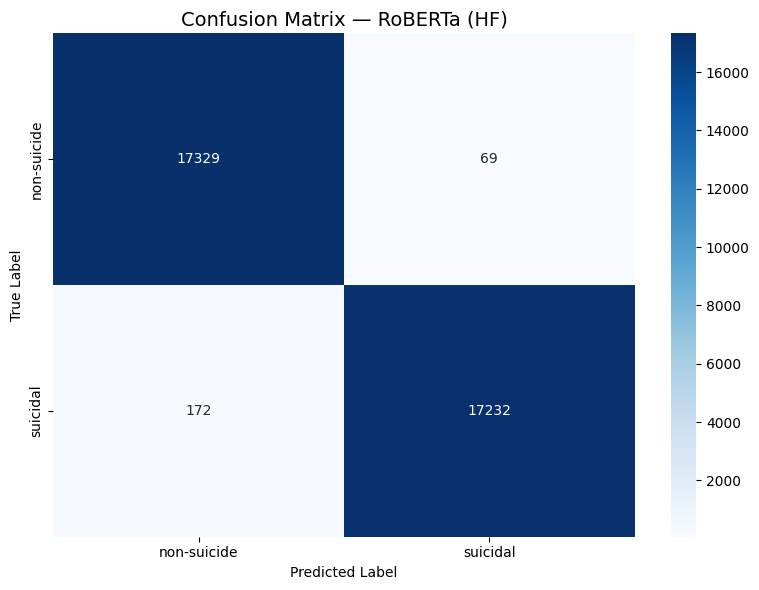


🎯 F1 Macro:              0.9931
🎯 F1 Weighted:           0.9931
🔥 Recall (suicidal cls): 0.9901  ← MOST IMPORTANT


In [ ]:
roberta_results = evaluate_model(
    model,
    tokenizer,
    test_df,
    model_name="RoBERTa (HF)"
)

## 🏆 Cell 18: Model Comparison & Auto-Select Best

In [ ]:
# comparison = pd.DataFrame([
#     {
#         'Model':             roberta_results['model_name'],
#         'F1 Macro':          round(roberta_results['f1_macro'], 4),
#         'F1 Weighted':       round(roberta_results['f1_weighted'], 4),
#         'Recall (class 1)':  round(roberta_results['recall_class1'], 4),
#     },
#     {
#         'Model':            deberta_results['model_name'],
#         'F1 Macro':         round(deberta_results['f1_macro'], 4),
#         'F1 Weighted':      round(deberta_results['f1_weighted'], 4),
#         'Recall (class 1)': round(deberta_results['recall_class1'], 4),
#     },


#     {
#         'Model':             distilbert_results['model_name'],
#         'F1 Macro':          round(distilbert_results['f1_macro'], 4),
#         'F1 Weighted':       round(distilbert_results['f1_weighted'], 4),
#         'Recall (class 1)':  round(distilbert_results['recall_class1'], 4),
#     }
# ])
# print("\n" + "="*60)
# print("  MODEL COMPARISON")
# print("="*60)
# print(comparison.to_string(index=False))

# # Auto-select best
# all_results = [roberta_results, distilbert_results, deberta_results]
# best_result = max(all_results, key=lambda x: x['recall_class1'])
# #
# best_model     = eval(f"{best_result['model_name'].lower()}_model")
# best_tokenizer = eval(f"{best_result['model_name'].lower()}_tokenizer")
# best_name      = best_result['model_name']

# print(f"\n✅ Best Model: {best_name}")

## 🔒 Cell 19: Inference Function with Safety Layer

In [ ]:
LABEL_MAP = {0: 'non-suicide', 1: 'suicidal', 2: 'indirect/context'}

def predict_text(text, model=None, tokenizer=None,
                 max_len=MAX_LEN, threshold=CONFIDENCE_THRESHOLD):
    """
    Predict suicide risk class for input text.

    Returns dict:
      - predicted_class : int (0/1/2 or -1 for invalid)
      - label           : str
      - confidence      : float
      - requires_review : bool  (True for suicidal / uncertain)
      - all_probs       : dict  {class_name: probability}
    """
    if model is None:
        model = best_model
    if tokenizer is None:
        tokenizer = best_tokenizer

    # Edge case: empty / invalid input
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            'predicted_class': -1,
            'label': 'invalid input',
            'confidence': 0.0,
            'requires_review': True,
            'all_probs': {},
        }

    cleaned = clean_text(text)
    if len(cleaned.strip()) == 0:
        return {
            'predicted_class': -1,
            'label': 'invalid input',
            'confidence': 0.0,
            'requires_review': True,
            'all_probs': {},
        }

    enc = tokenizer(
        cleaned,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

    model.eval()
    with torch.no_grad():
        outputs = model(
            input_ids      = enc['input_ids'].to(DEVICE),
            attention_mask = enc['attention_mask'].to(DEVICE)
        )
        probs      = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    pred_class = int(np.argmax(probs))
    confidence = float(probs[pred_class])

    # ── Safety Layer ────────────────────────────────────────────
    if confidence < threshold:
        label          = 'uncertain — needs human review'
        requires_review = True
    else:
        label          = LABEL_MAP[pred_class]
        requires_review = pred_class in [1, 2]  # flag all suicide-related
    # ─────────────────────────────────────────────────────────────

    return {
        'predicted_class': pred_class,
        'label':           label,
        'confidence':      round(confidence, 4),
        'requires_review': requires_review,
        'all_probs': {
            'non-suicide':      round(float(probs[0]), 4),
            'suicidal':         round(float(probs[1]), 4),
            'indirect/context': round(float(probs[2]), 4),
        },
    }

print("✅ predict_text() inference function ready")

## 🧪 Cell 20: Test Inference on Sample Texts

In [ ]:
test_samples = [
    "I can't take it anymore, I just want to end everything tonight.",
    "My friend told me he's been thinking about killing himself.",
    "Just had a great day at the park with my family!",
    "i need help im crying so hard",
    "Do you think getting hit by a train would be painful?",
    "I feel a little sad today but overall okay.",
    "Ex wife threatening suicide, she keeps calling me.",
    "",    # edge case: empty string
    "   ", # edge case: whitespace only
]

print("\n" + "="*80)
print("  INFERENCE RESULTS")
print("="*80)

for sample in test_samples:
    result = predict_text(sample)
    flag   = "⚠️  REVIEW NEEDED" if result['requires_review'] else "✅ SAFE"
    display_text = (sample[:65] + "...") if len(sample) > 65 else (sample or "[empty]")
    print(f"\nText       : {display_text}")
    print(f"Label      : {result['label']}")
    print(f"Confidence : {result['confidence']}")
    print(f"Status     : {flag}")
    print(f"All probs  : {result['all_probs']}")

## ✅ Cell 21: Final Summary

In [ ]:
print("\n" + "="*60)
print("  PIPELINE COMPLETE ✅")
print("="*60)
print(f"  Best Model             : {best_name}")
print(f"  Number of Classes      : {NUM_LABELS}  (non-suicide | suicidal | indirect)")
print(f"  Max Sequence Length    : {MAX_LEN}")
print(f"  Confidence Threshold   : {CONFIDENCE_THRESHOLD}")
print(f"  RoBERTa saved at       : {SAVE_DIR_ROBERTA}")
print(f"  DistilBERT saved at    : {SAVE_DIR_DISTILBERT}")
print()
print("⚠️  SAFETY NOTE:")
print("   Model outputs must always be reviewed by a human")
print("   for high-stakes decisions. Never deploy without")
print("   a human-in-the-loop review system.")

In [ ]:
from huggingface_hub import login, HfApi
import os

# Step 1: Login
from google.colab import userdata
token = userdata.get('Suicede_key')
login(token=token)

# Step 2: Upload files
api = HfApi()

files = {
    "/content/drive/MyDrive/Colab Notebooks/suicide detection/app.py": "app.py",
    "/content/drive/MyDrive/Colab Notebooks/suicide detection/requirements.txt": "requirements.txt",
}

for local_path, repo_path in files.items():
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=repo_path,
        repo_id="Shahid-0039/Suicide_detection",
        repo_type="space"
    )
    print(f"✅ {repo_path} uploaded!")

print("\n🚀 Space live: https://huggingface.co/spaces/Shahid-0039/Suicide_detection")